In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Data Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Data Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Data Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Data Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Data Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Data Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Data Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Data Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [3]:
print("Columns in df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.columns)
print("Columns in df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.columns)

Columns in df_with_selected_features_and_all_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')
Columns in df_with_selected_features_and_no_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')


In [4]:
print("Columns in df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.columns)
print("Columns in df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.columns)

Columns in df_with_all_outliers_and_all_features:  Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

# **XGBoost Classifier without Hyperparameter Tuning**

In [5]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(
    X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42, stratify=y_a_o_a_f
)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(
    X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42, stratify=y_a_o_s_f
)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(
    X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42, stratify=y_n_o_a_f
)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(
    X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42, stratify=y_n_o_s_f
)

In [6]:
xgb_a_o_a_f = XGBClassifier(random_state=42)
xgb_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
xgb_a_o_s_f = XGBClassifier(random_state=42)
xgb_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
xgb_n_o_a_f = XGBClassifier(random_state=42)
xgb_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
xgb_n_o_s_f = XGBClassifier(random_state=42)
xgb_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

xgb_a_o_a_f_pred = xgb_a_o_a_f.predict(X_test_a_o_a_f)
xgb_a_o_s_f_pred = xgb_a_o_s_f.predict(X_test_a_o_s_f)
xgb_n_o_a_f_pred = xgb_n_o_a_f.predict(X_test_n_o_a_f)
xgb_n_o_s_f_pred = xgb_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - XGBoost Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, xgb_a_o_a_f_pred))
print("Classification Report - XGBoost Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, xgb_a_o_s_f_pred))

Classification Report - XGBoost Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.79      0.74      0.77       284
           1       0.51      0.45      0.48       159
           2       0.82      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.70       885
weighted avg       0.76      0.76      0.76       885

Classification Report - XGBoost Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       284
           1       0.43      0.35      0.39       159
           2       0.80      0.87      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.74      0.73       885



In [7]:
print("Classification Report - XGBoost Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, xgb_n_o_a_f_pred))
print("Classification Report - XGBoost Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, xgb_n_o_s_f_pred))

Classification Report - XGBoost Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       279
           1       0.50      0.38      0.43       155
           2       0.81      0.89      0.84       433

    accuracy                           0.76       867
   macro avg       0.70      0.68      0.69       867
weighted avg       0.75      0.76      0.75       867

Classification Report - XGBoost Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       279
           1       0.40      0.32      0.36       155
           2       0.77      0.87      0.82       433

    accuracy                           0.72       867
   macro avg       0.65      0.63      0.64       867
weighted avg       0.71      0.72      0.71       867



Confusion Matrix - XGBoost Classifier with All Outliers and All Features:


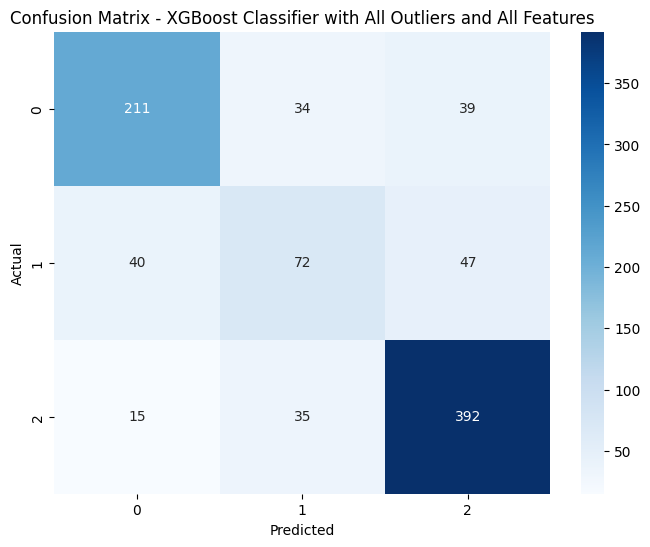

Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features:


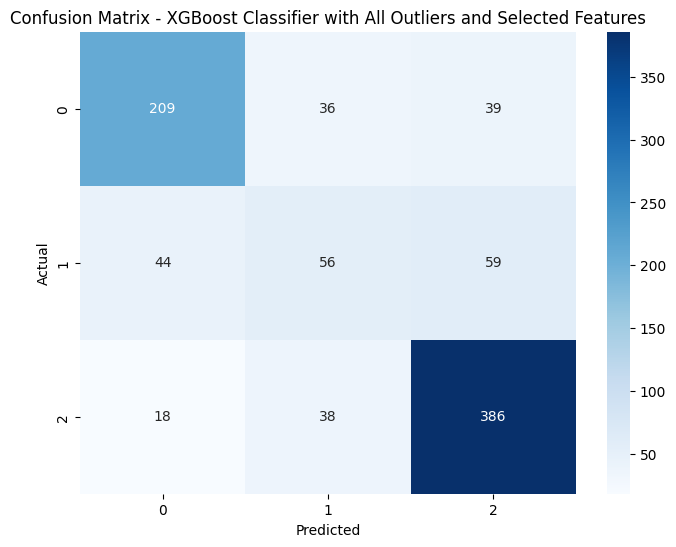

Confusion Matrix - XGBoost Classifier with No Outliers and All Features:


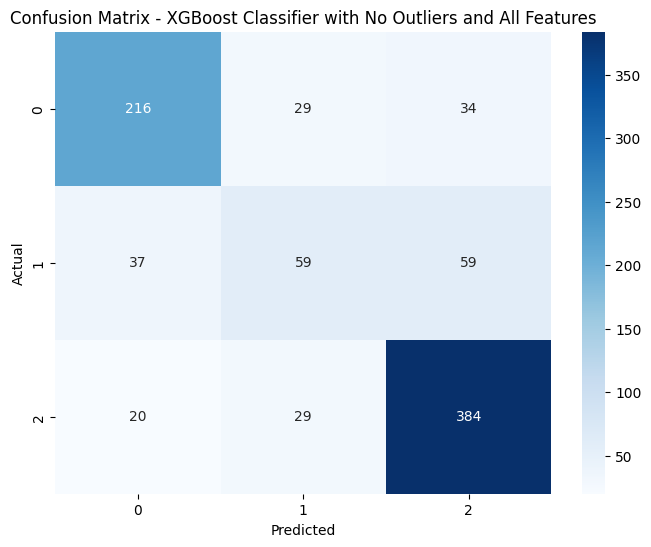

Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features:


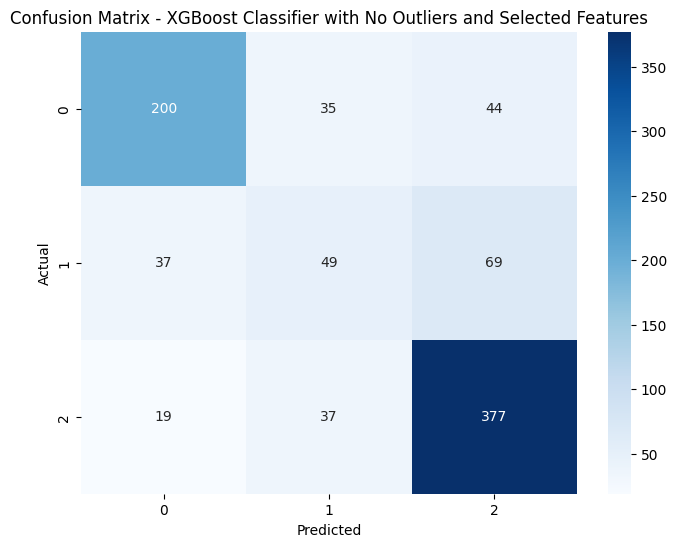

In [8]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - XGBoost Classifier with All Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, xgb_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, xgb_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, xgb_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, xgb_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Accuracy Score
print("Accuracy Score - XGBoost Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, xgb_a_o_a_f_pred))
print("Accuracy Score - XGBoost Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, xgb_a_o_s_f_pred))
print("Accuracy Score - XGBoost Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, xgb_n_o_a_f_pred))
print("Accuracy Score - XGBoost Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, xgb_n_o_s_f_pred))

Accuracy Score - XGBoost Classifier with All Outliers and All Features: 0.7627118644067796
Accuracy Score - XGBoost Classifier with All Outliers and Selected Features: 0.735593220338983
Accuracy Score - XGBoost Classifier with No Outliers and All Features: 0.7600922722029988
Accuracy Score - XGBoost Classifier with No Outliers and Selected Features: 0.7220299884659747


In [10]:
# ROC AUC Score
print("ROC AUC Score - XGBoost Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, xgb_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, xgb_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, xgb_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, xgb_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - XGBoost Classifier with All Outliers and All Features: 0.8854144549169757
ROC AUC Score - XGBoost Classifier with All Outliers and Selected Features: 0.8428754767034156
ROC AUC Score - XGBoost Classifier with No Outliers and All Features: 0.8756728497584025
ROC AUC Score - XGBoost Classifier with No Outliers and Selected Features: 0.8367211752108291


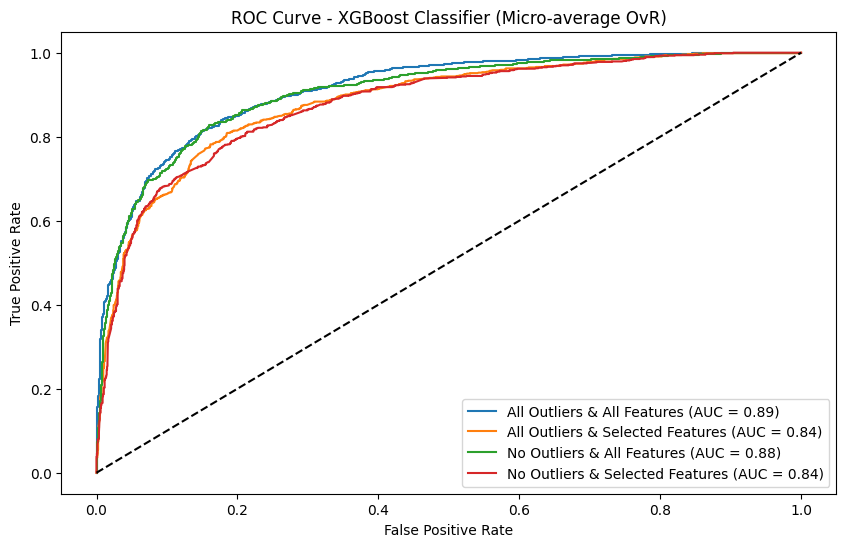

In [11]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, xgb_a_o_a_f.predict_proba(X_test_a_o_a_f), xgb_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, xgb_a_o_s_f.predict_proba(X_test_a_o_s_f), xgb_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, xgb_n_o_a_f.predict_proba(X_test_n_o_a_f), xgb_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, xgb_n_o_s_f.predict_proba(X_test_n_o_s_f), xgb_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

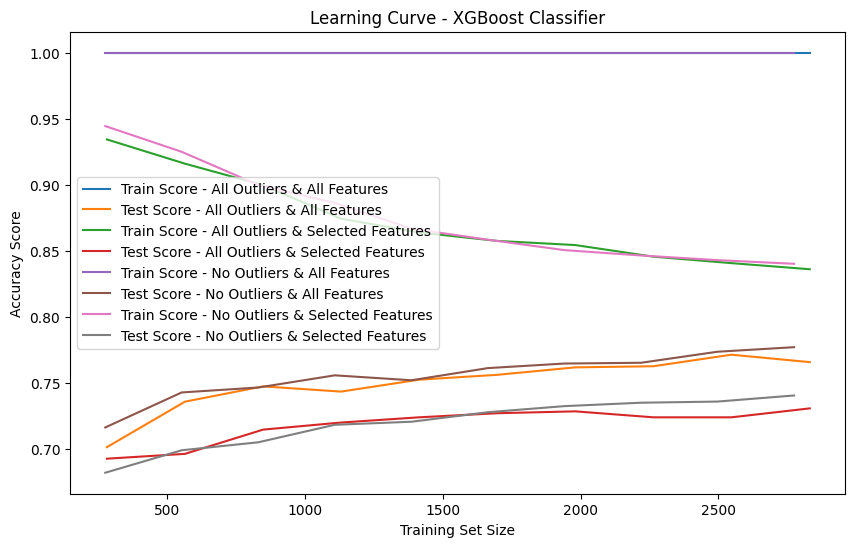

In [12]:
# Learning Curve
train_sizes_a_o_a_f, train_scores_a_o_a_f, test_scores_a_o_a_f = learning_curve(
    xgb_a_o_a_f, X_train_a_o_a_f, y_train_a_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_a_o_s_f, train_scores_a_o_s_f, test_scores_a_o_s_f = learning_curve(
    xgb_a_o_s_f, X_train_a_o_s_f, y_train_a_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_a_f, train_scores_n_o_a_f, test_scores_n_o_a_f = learning_curve(
    xgb_n_o_a_f, X_train_n_o_a_f, y_train_n_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_s_f, train_scores_n_o_s_f, test_scores_n_o_s_f = learning_curve(
    xgb_n_o_s_f, X_train_n_o_s_f, y_train_n_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_a_o_a_f, np.mean(train_scores_a_o_a_f, axis=1), label='Train Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_a_f, np.mean(test_scores_a_o_a_f, axis=1), label='Test Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_s_f, np.mean(train_scores_a_o_s_f, axis=1), label='Train Score - All Outliers & Selected Features')
plt.plot(train_sizes_a_o_s_f, np.mean(test_scores_a_o_s_f, axis=1), label='Test Score - All Outliers & Selected Features')
plt.plot(train_sizes_n_o_a_f, np.mean(train_scores_n_o_a_f, axis=1), label='Train Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_a_f, np.mean(test_scores_n_o_a_f, axis=1), label='Test Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_s_f, np.mean(train_scores_n_o_s_f, axis=1), label='Train Score - No Outliers & Selected Features')
plt.plot(train_sizes_n_o_s_f, np.mean(test_scores_n_o_s_f, axis=1), label='Test Score - No Outliers & Selected Features')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - XGBoost Classifier')
plt.legend(loc='best')
plt.show()

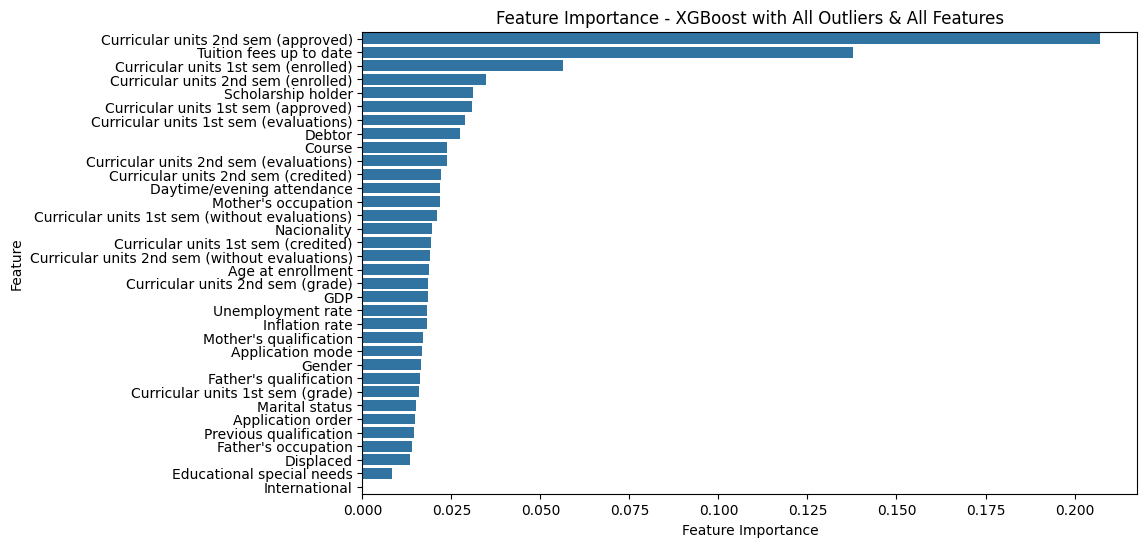

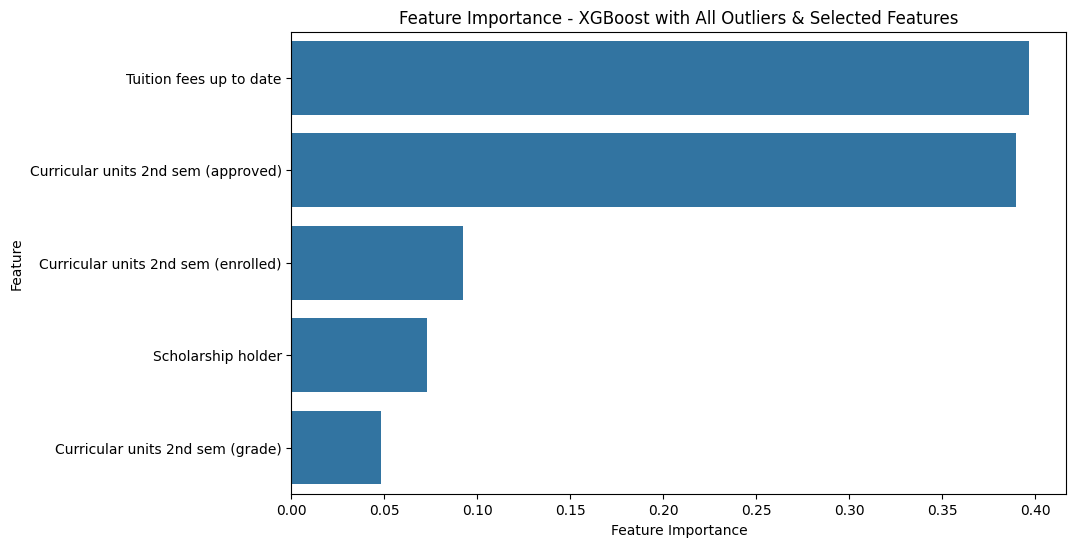

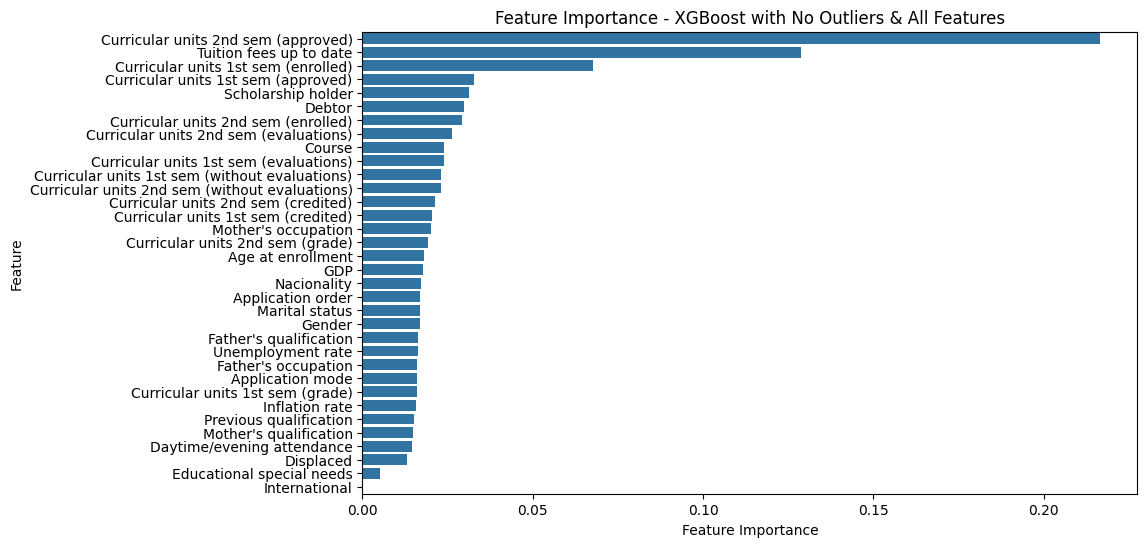

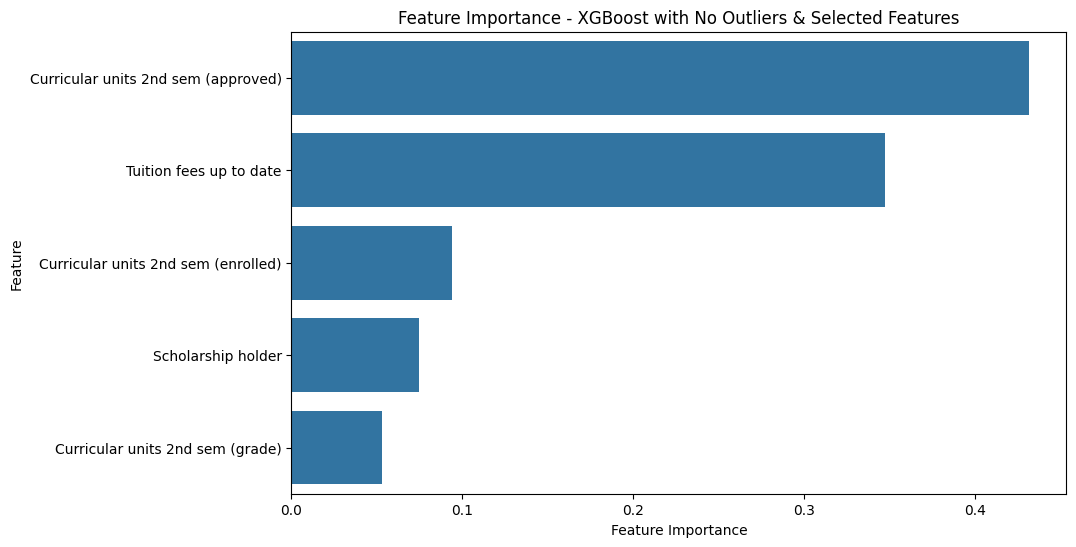

In [13]:
def plot_feature_importance(model, feature_names, title):
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[indices], y=np.array(feature_names)[indices])
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()
plot_feature_importance(xgb_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - XGBoost with All Outliers & All Features")
plot_feature_importance(xgb_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - XGBoost with All Outliers & Selected Features")
plot_feature_importance(xgb_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - XGBoost with No Outliers & All Features")
plot_feature_importance(xgb_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - XGBoost with No Outliers & Selected Features")

## **Model Evaluation Summary (Updated from Latest Rerun)**

The best tuned configuration in this notebook is:
**XGBoost Classifier with All Outliers and All Features**

### Key Metrics (Tuned Models)
- **Accuracy**: 0.7751 (best)
- **ROC-AUC**: 0.8905 (best)
- **5-Fold CV (AOAF)**: mean 0.7799, std 0.0102

### Interpretation
- All-features variants remain stronger than selected-feature variants for XGBoost in this rerun.
- Outlier-retained data still provides useful predictive signal when boosted trees are tuned and regularized.
- XGBoost gives the highest discrimination quality in this notebook (ROC-AUC).

### Conclusion
Deploy candidate from this notebook: **Tuned XGBoost (All Outliers + All Features)**.

# **XGBoost with Hyperparameter Tuning**

## **Coarse-to-Fine-Search**

### **RandomSearchCV**

In [ ]:
# param_dist_xgb = {
#     'n_estimators'      : np.arange(100, 1001, 100),
#     'max_depth'         : np.arange(3, 11),
#     'learning_rate'     : [0.01, 0.05, 0.1, 0.2, 0.3],
#     'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
#     'min_child_weight'  : np.arange(1, 11),
#     'gamma'             : [0, 0.1, 0.2, 0.3, 0.5],
#     'reg_alpha'         : [0, 0.01, 0.1, 0.5, 1.0],
#     'reg_lambda'        : [0.5, 1.0, 1.5, 2.0, 5.0]
# }

# random_search_xgb1 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Hyperparameters for XGBoost Classifier with All Outliers and Selected Features (Randomized Search):")
# print(random_search_xgb1.best_params_)

# random_search_xgb2 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Hyperparameters for XGBoost Classifier with No Outliers and Selected Features (Randomized Search):")
# print(random_search_xgb2.best_params_)

# random_search_xgb3 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Hyperparameters for XGBoost Classifier with All Outliers and All Features (Randomized Search):")
# print(random_search_xgb3.best_params_)

# random_search_xgb4 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Hyperparameters for XGBoost Classifier with No Outliers and All Features (Randomized Search):")
# print(random_search_xgb4.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with All Outliers and Selected Features (Randomized Search):
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': np.int64(300), 'min_child_weight': np.int64(1), 'max_depth': np.int64(3), 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.9}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with No Outliers and Selected Features (Randomized Search):
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': np.int64(1000), 'min_child_weight': np.int64(9), 'max_depth': np.int64(4), 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with All Outliers and All Features (Randomized Search):
{'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'n_estimators': np.int64(400)

### **GridSearchCV**

In [ ]:
# param_grid_xgb1 = {
#     'n_estimators'     : [200, 300, 400],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.05, 0.1, 0.15],        
#     'min_child_weight' : [1, 2, 3],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.9],          
#     'gamma'            : [0.5],          
#     'reg_alpha'        : [0.5],          
#     'reg_lambda'       : [2.0],          
# }

# grid_xgb1 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb1, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Params XGB1:", grid_xgb1.best_params_)
# print("Best Score  XGB1:", grid_xgb1.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB1: {'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 1.0}
Best Score  XGB1: 0.759537793973102


In [ ]:
# param_grid_xgb2 = {
#     'n_estimators'     : [800, 1000, 1200],    
#     'max_depth'        : [3, 4, 5],            
#     'learning_rate'    : [0.005, 0.01, 0.05],  
#     'min_child_weight' : [7, 9, 11],           
#     'subsample'        : [0.8, 0.9, 1.0],                
#     'colsample_bytree' : [0.7],                
#     'gamma'            : [0.5],                
#     'reg_alpha'        : [0.01],               
#     'reg_lambda'       : [2.0],                
# }

# grid_xgb2 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Params XGB2:", grid_xgb2.best_params_)
# print("Best Score  XGB2:", grid_xgb2.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB2: {'colsample_bytree': 0.7, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 1000, 'reg_alpha': 0.01, 'reg_lambda': 2.0, 'subsample': 1.0}
Best Score  XGB2: 0.7572089773818881


In [ ]:
# param_grid_xgb3 = {
#     'n_estimators'     : [300, 400, 500],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.05, 0.1, 0.15],        
#     'min_child_weight' : [3, 4, 5],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.7],          
#     'gamma'            : [0],            
#     'reg_alpha'        : [1.0],          
#     'reg_lambda'       : [1.5],          
# }

# grid_xgb3 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb3, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Params XGB3:", grid_xgb3.best_params_)
# print("Best Score  XGB3:", grid_xgb3.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB3: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.15, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 400, 'reg_alpha': 1.0, 'reg_lambda': 1.5, 'subsample': 0.9}
Best Score  XGB3: 0.7860978591805912


In [ ]:
# param_grid_xgb4 = {
#     'n_estimators'     : [300, 400, 500],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.1, 0.2, 0.3],          
#     'min_child_weight' : [4, 5, 6],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.6],          
#     'gamma'            : [0.5],            
#     'reg_alpha'        : [0.01],        
#     'reg_lambda'       : [1.5],          
# }

# grid_xgb4 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb4, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Params XGB4:", grid_xgb4.best_params_)
# print("Best Score  XGB4:", grid_xgb4.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB4: {'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1.5, 'subsample': 1.0}
Best Score  XGB4: 0.7828723629876368


#### **Note: GridSearchCV Configuration**

The original configuration was **not used** due to hardware limitations (Axioo Hype 5 AMD — Ryzen 5 6600H, no CUDA GPU). The full grid would generate **98,415 fits** and take approximately **90–150 minutes** to complete, causing 100% CPU usage.

The following code was **skipped**:

```python
# ❌ NOT USED — Estimated runtime: ~90–150 minutes | Total fits: 98,415 | CPU: ~100%
param_grid_xgb2 = {
    'n_estimators'     : [800, 1000, 1200],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.005, 0.01, 0.05],
    'subsample'        : [0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8],
    'min_child_weight' : [7, 9, 11],
    'gamma'            : [0.3, 0.5, 0.7],
    'reg_alpha'        : [0.01, 0.05, 0.1],
    'reg_lambda'       : [1.5, 2.0, 2.5],
}
grid_xgb2 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
```

Instead, the optimized configuration below was used by fixing parameters already validated by RandomizedSearchCV (`subsample`, `colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda`) and only searching the 4 highest-impact parameters, reducing total fits from **98,415 → 405** with actual runtime of only **~1–2 minutes**.

```python
# ✅ USED — Actual runtime: ~1–2 minutes | Total fits: 405 | CPU: ~60–80%
param_grid_xgb2 = {
    'n_estimators'     : [800, 1000, 1200],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.005, 0.01, 0.05],
    'min_child_weight' : [7, 9, 11],
    'subsample'        : [1.0],            # fixed from RandomizedSearch
    'colsample_bytree' : [0.7],            # fixed from RandomizedSearch
    'gamma'            : [0.5],            # fixed from RandomizedSearch
    'reg_alpha'        : [0.01],           # fixed from RandomizedSearch
    'reg_lambda'       : [2.0],            # fixed from RandomizedSearch
}
grid_xgb2 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
```

## **IMPLEMENTATION TO THE MODELS WITH THE RESULTS OF** ***Coarse-to-Fine-Search***

In [14]:
xgb_tuned_a_o_s_f = XGBClassifier(
    colsample_bytree=0.9, learning_rate=0.05, max_depth=4,
    min_child_weight=3, n_estimators=300, reg_alpha=0.5,
    reg_lambda=2.0, subsample=1.0, gamma=0.5,
    random_state=42, eval_metric='mlogloss', use_label_encoder=False
)
xgb_tuned_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)

xgb_tuned_n_o_s_f = XGBClassifier(
    colsample_bytree=0.5, learning_rate=0.01, max_depth=4,
    min_child_weight=7, n_estimators=1000, reg_alpha=0.01,
    reg_lambda=2.0, subsample=1.0, gamma=0.5,
    random_state=42, eval_metric='mlogloss', use_label_encoder=False
)
xgb_tuned_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

xgb_tuned_a_o_a_f = XGBClassifier(
    colsample_bytree=0.7, learning_rate=0.15, max_depth=2,
    min_child_weight=3, n_estimators=400, reg_alpha=0.1,
    reg_lambda=1.5, subsample=0.9, gamma=0,
    random_state=42, eval_metric='mlogloss', use_label_encoder=False
)
xgb_tuned_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)

xgb_tuned_n_o_a_f = XGBClassifier(
    colsample_bytree=0.6, learning_rate=0.2, max_depth=3,
    min_child_weight=4, n_estimators=300, reg_alpha=0.01,
    reg_lambda=1.5, subsample=0.9, gamma=0.5,
    random_state=42, eval_metric='mlogloss', use_label_encoder=False
)
xgb_tuned_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)

xgb_tuned_a_o_s_f_pred = xgb_tuned_a_o_s_f.predict(X_test_a_o_s_f)
xgb_tuned_n_o_s_f_pred = xgb_tuned_n_o_s_f.predict(X_test_n_o_s_f)
xgb_tuned_a_o_a_f_pred = xgb_tuned_a_o_a_f.predict(X_test_a_o_a_f)
xgb_tuned_n_o_a_f_pred = xgb_tuned_n_o_a_f.predict(X_test_n_o_a_f)

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores_xgb_best = cross_val_score(
    xgb_tuned_a_o_a_f,
    X_train_a_o_a_f,
    y_train_a_o_a_f,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Score (5-Fold) - Tuned XGBoost (All Outliers + All Features):")
print("CV Scores:", np.round(cv_scores_xgb_best, 4))
print("Mean CV Accuracy:", round(cv_scores_xgb_best.mean(), 4))
print("Std CV Accuracy :", round(cv_scores_xgb_best.std(), 4))

Cross Validation Score (5-Fold) - Tuned XGBoost (All Outliers + All Features):
CV Scores: [0.7669 0.7966 0.7768 0.774  0.785 ]
Mean CV Accuracy: 0.7799
Std CV Accuracy : 0.0102


In [16]:
# Classification Report after Hyperparameter Tuning with Coarse-to-Fine Search
print("Classification Report - Tuned XGBoost Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, xgb_tuned_a_o_s_f_pred))
print("Classification Report - Tuned XGBoost Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, xgb_tuned_n_o_s_f_pred))

Classification Report - Tuned XGBoost Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       284
           1       0.47      0.31      0.38       159
           2       0.80      0.93      0.86       442

    accuracy                           0.76       885
   macro avg       0.68      0.66      0.67       885
weighted avg       0.74      0.76      0.74       885

Classification Report - Tuned XGBoost Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       279
           1       0.40      0.26      0.31       155
           2       0.77      0.91      0.84       433

    accuracy                           0.74       867
   macro avg       0.66      0.64      0.64       867
weighted avg       0.72      0.74      0.72       867



In [17]:
print("Classification Report - Tuned XGBoost Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, xgb_tuned_a_o_a_f_pred))
print("Classification Report - Tuned XGBoost Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, xgb_tuned_n_o_a_f_pred))

Classification Report - Tuned XGBoost Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       284
           1       0.55      0.44      0.49       159
           2       0.81      0.91      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.70      0.71       885
weighted avg       0.77      0.78      0.77       885

Classification Report - Tuned XGBoost Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       279
           1       0.50      0.42      0.46       155
           2       0.80      0.88      0.84       433

    accuracy                           0.76       867
   macro avg       0.71      0.69      0.70       867
weighted avg       0.76      0.76      0.76       867



Confusion Matrix - Tuned XGBoost Classifier with All Outliers and All Features after:


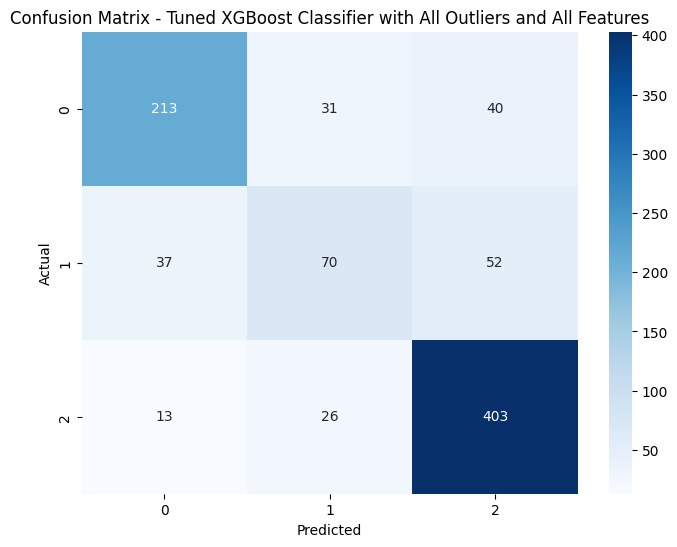

Confusion Matrix - Tuned XGBoost Classifier with All Outliers and Selected Features:


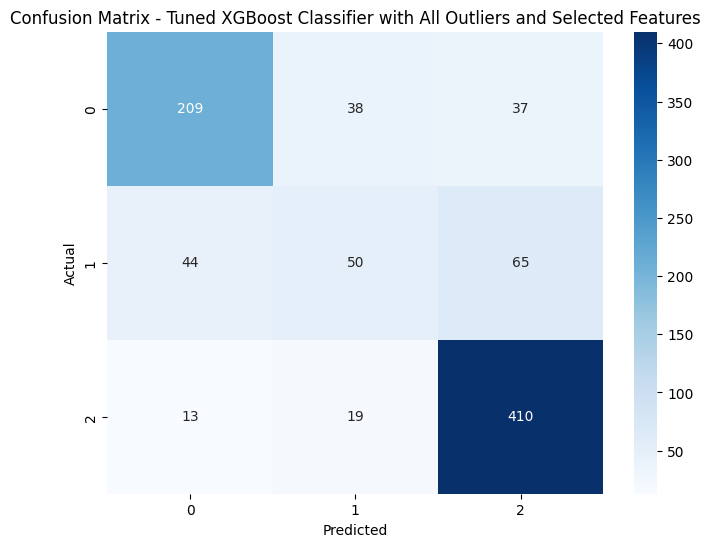

Confusion Matrix - Tuned XGBoost Classifier with No Outliers and All Features:


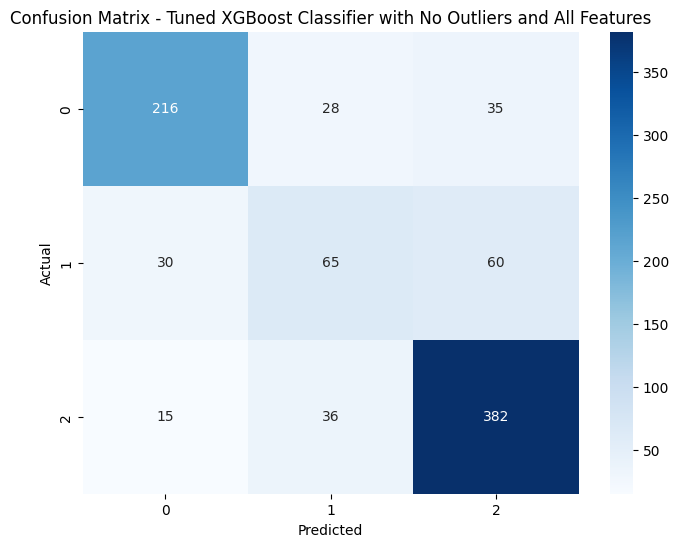

Confusion Matrix - Tuned XGBoost Classifier with No Outliers and Selected Features:


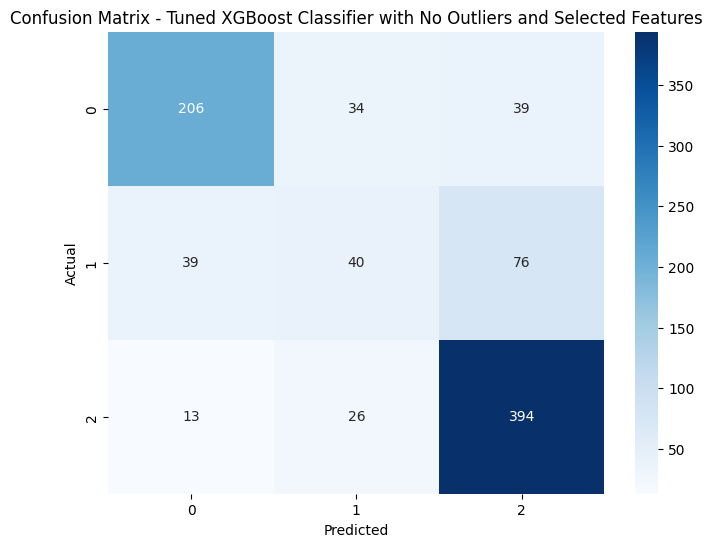

In [18]:
# Plot Confusion Matrix Chart after Hyperparameter Tuning with Coarse-to-Fine Search
print("Confusion Matrix - Tuned XGBoost Classifier with All Outliers and All Features after:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, xgb_tuned_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned XGBoost Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, xgb_tuned_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned XGBoost Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, xgb_tuned_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned XGBoost Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, xgb_tuned_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Accuracy Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("Accuracy Score - Tuned XGBoost Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, xgb_tuned_a_o_s_f_pred))
print("Accuracy Score - Tuned XGBoost Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, xgb_tuned_n_o_s_f_pred))
print("Accuracy Score - Tuned XGBoost Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, xgb_tuned_a_o_a_f_pred))
print("Accuracy Score - Tuned XGBoost Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, xgb_tuned_n_o_a_f_pred))

Accuracy Score - Tuned XGBoost Classifier with All Outliers and Selected Features: 0.7559322033898305
Accuracy Score - Tuned XGBoost Classifier with No Outliers and Selected Features: 0.7381776239907728
Accuracy Score - Tuned XGBoost Classifier with All Outliers and All Features: 0.7751412429378531
Accuracy Score - Tuned XGBoost Classifier with No Outliers and All Features: 0.7647058823529411


In [20]:
# Roc AUC Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("ROC AUC Score - Tuned XGBoost Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, xgb_tuned_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned XGBoost Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, xgb_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned XGBoost Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, xgb_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Tuned XGBoost Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, xgb_tuned_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))

ROC AUC Score - Tuned XGBoost Classifier with All Outliers and Selected Features: 0.8621700567537204
ROC AUC Score - Tuned XGBoost Classifier with No Outliers and Selected Features: 0.8536117765068943
ROC AUC Score - Tuned XGBoost Classifier with All Outliers and All Features: 0.8905479967884707
ROC AUC Score - Tuned XGBoost Classifier with No Outliers and All Features: 0.877322488846986


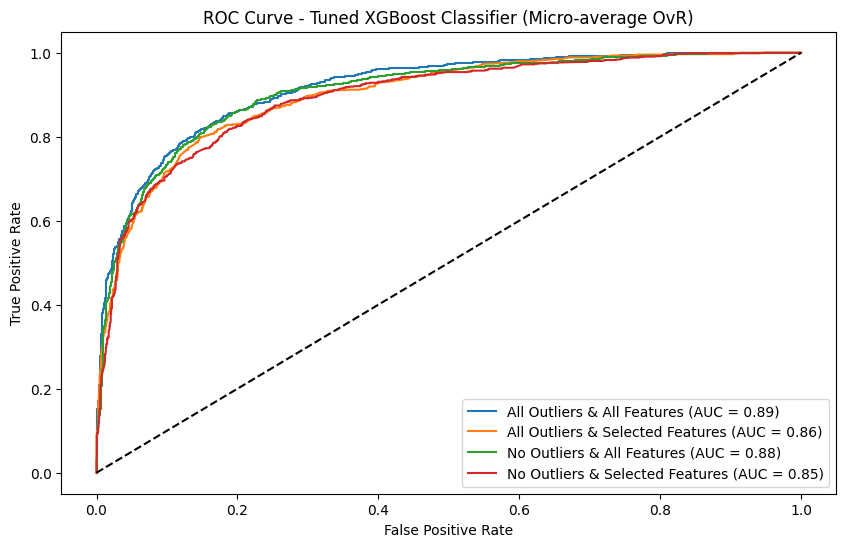

In [21]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, xgb_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), xgb_tuned_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, xgb_tuned_a_o_s_f.predict_proba(X_test_a_o_s_f), xgb_tuned_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, xgb_tuned_n_o_a_f.predict_proba(X_test_n_o_a_f), xgb_tuned_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, xgb_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), xgb_tuned_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

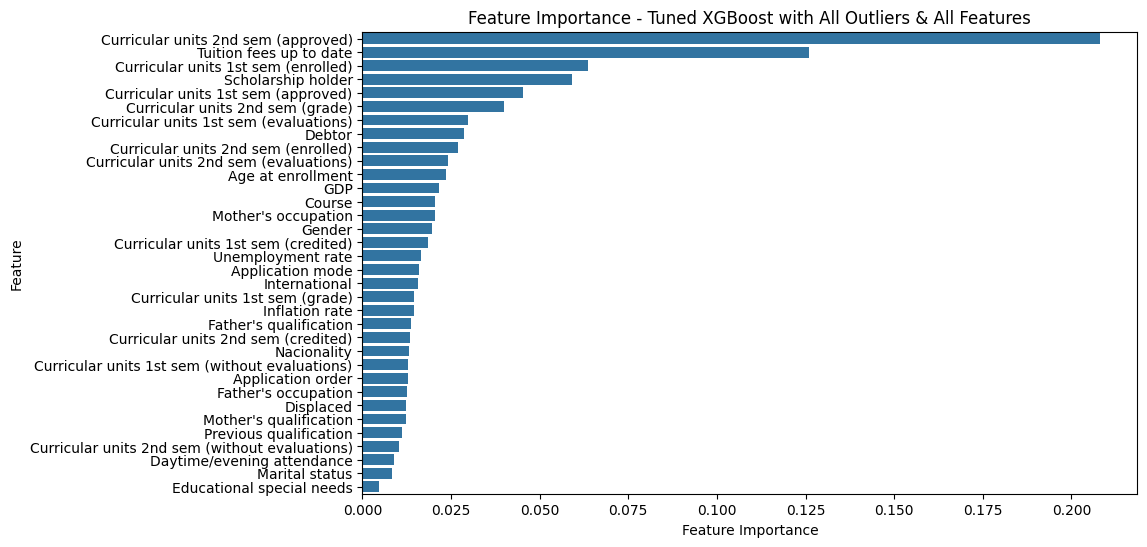

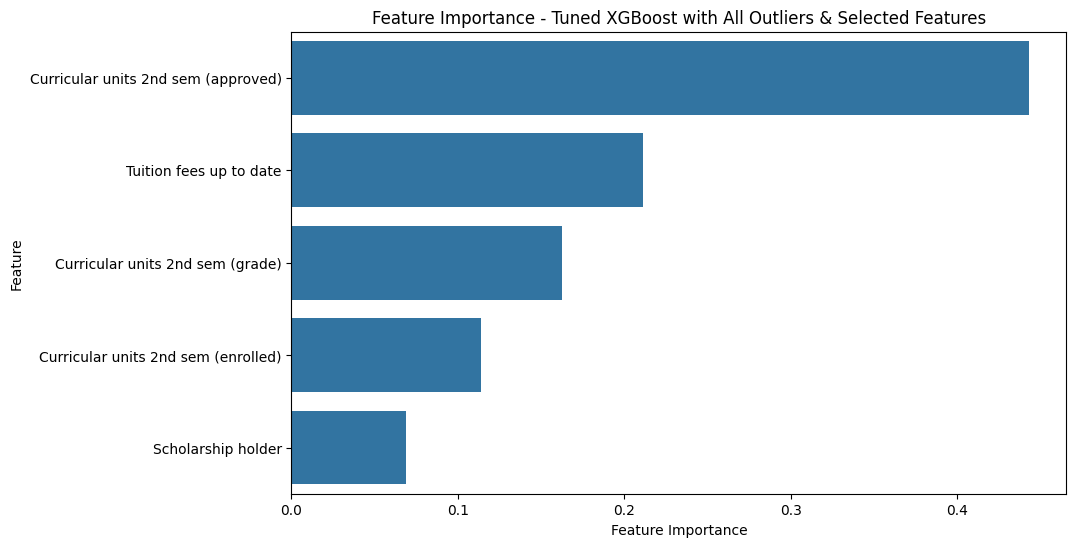

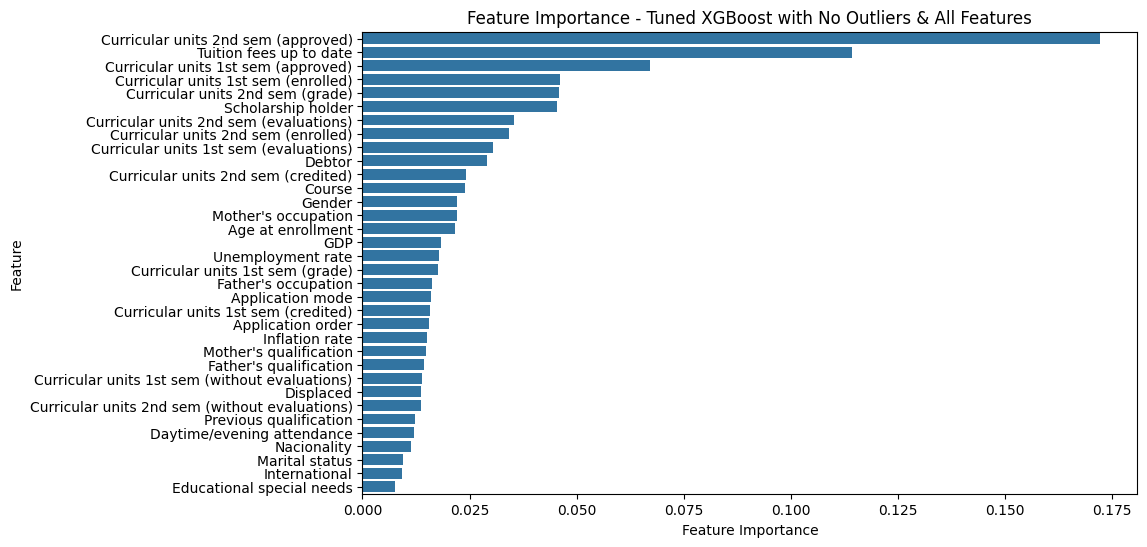

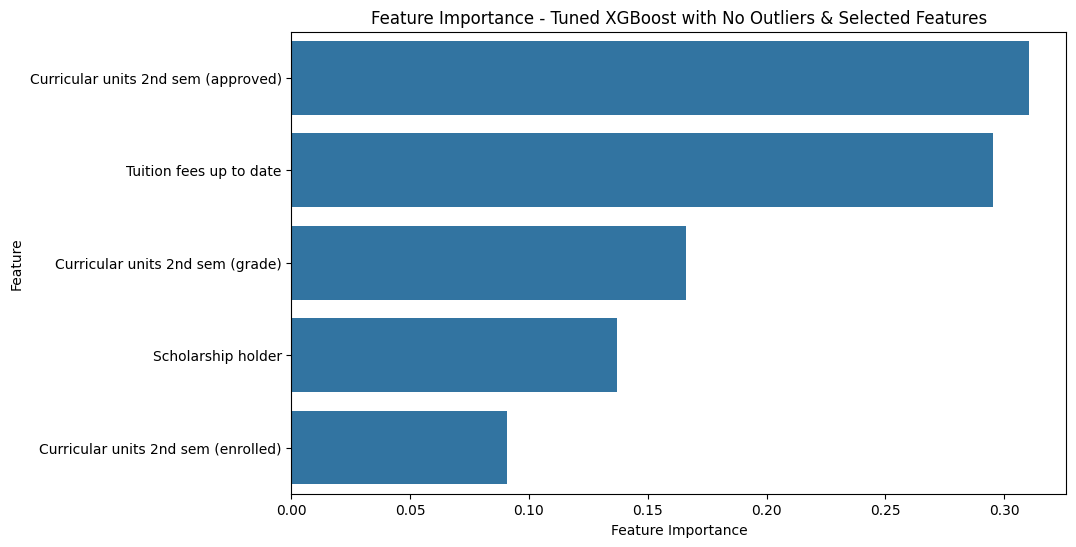

In [22]:
plot_feature_importance(xgb_tuned_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Tuned XGBoost with All Outliers & All Features")
plot_feature_importance(xgb_tuned_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Tuned XGBoost with All Outliers & Selected Features")
plot_feature_importance(xgb_tuned_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Tuned XGBoost with No Outliers & All Features")
plot_feature_importance(xgb_tuned_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Tuned XGBoost with No Outliers & Selected Features")

# **XGBoost Model Evaluation Report (Synced to Latest Rerun)**
**Project:** Classification with XGBoost  
**Tuning Method:** Coarse-to-Fine Search (RandomizedSearchCV -> GridSearchCV)  
**Validation:** Test split + 5-Fold CV (for tuned AOAF)

---

## 1. Tuned Model Results (Latest Rerun)

| Scenario | Accuracy | ROC-AUC |
|---|---:|---:|
| All Outliers + Selected Features | 0.7559 | 0.8622 |
| No Outliers + Selected Features | 0.7382 | 0.8536 |
| **All Outliers + All Features** | **0.7751** | **0.8905** |
| No Outliers + All Features | 0.7647 | 0.8773 |

### Cross Validation (Tuned AOAF)
- CV Mean (5-Fold): **0.7799**
- CV Std (5-Fold): **0.0102**

---

## 2. Key Findings
- Konfigurasi terbaik tetap **All Outliers + All Features**.
- All-features konsisten unggul atas selected-features pada XGBoost dalam rerun ini.
- Outlier-retained data tetap memberikan sinyal prediktif yang kuat saat tuning/regularisasi diterapkan.

---

## 3. Final Recommendation
Gunakan **Tuned XGBoost (All Outliers + All Features)** sebagai kandidat produksi utama dari notebook XGBoost ini.

In [23]:
from sklearn.model_selection import cross_val_score

MODEL_DIR = "../models/xgboost_classifier_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# Generate timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the best model (Tuned XGBoost - All Outliers + All Features)
best_xgb_model = xgb_tuned_a_o_a_f
model_filename = f"best_xgb_classifier_model_{timestamp}.pkl"
model_path = os.path.join(MODEL_DIR, model_filename)
joblib.dump(best_xgb_model, model_path)

model_params = best_xgb_model.get_params()
feature_names = X_train_a_o_a_f.columns.tolist()
feature_importances = best_xgb_model.feature_importances_

feature_importance_dict = [
    {
        'feature': name,
        'importance': round(float(score), 6),
        'percentage': f"{round(float(score) * 100, 2)}%"
    }
    for name, score in sorted(
        zip(feature_names, feature_importances),
        key=lambda x: x[1],
        reverse=True
    )
]

cv_scores_xgb_save = cross_val_score(
    best_xgb_model,
    X_train_a_o_a_f,
    y_train_a_o_a_f,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Create metadata for the saved model
model_metadata = {
    'model_name': 'Tuned XGBoost Classifier with All Outliers and All Features',
    'description': 'This model is an XGBoost Classifier tuned using GridSearchCV with a coarse-to-fine search strategy. It was trained on data_cleaned_with_all_outliers_and_all_features.csv.',
    'training_data': {
        'dataset': 'data_cleaned_with_all_outliers_and_all_features.csv',
        'features': feature_names,
        'target': 'Target',
        'train_test_split': '80% train, 20% test (stratify=Target)',
        'random_state': 42
    },
    'hyperparameters': {
        'n_estimators': model_params['n_estimators'],
        'max_depth': model_params['max_depth'],
        'learning_rate': model_params['learning_rate'],
        'min_child_weight': model_params['min_child_weight'],
        'subsample': model_params['subsample'],
        'colsample_bytree': model_params['colsample_bytree'],
        'gamma': model_params['gamma'],
        'reg_alpha': model_params['reg_alpha'],
        'reg_lambda': model_params['reg_lambda']
    },
    'performance': {
        'accuracy': float(accuracy_score(y_test_a_o_a_f, xgb_tuned_a_o_a_f_pred)),
        'roc_auc': float(roc_auc_score(y_test_a_o_a_f, best_xgb_model.predict_proba(X_test_a_o_a_f), multi_class='ovr')),
        'classification_report': classification_report(y_test_a_o_a_f, xgb_tuned_a_o_a_f_pred, output_dict=True)
    },
    'cross_validation': {
        'cv': 5,
        'scoring': 'accuracy',
        'scores': [float(score) for score in cv_scores_xgb_save],
        'mean': float(cv_scores_xgb_save.mean()),
        'std': float(cv_scores_xgb_save.std())
    },
    'feature_importance': feature_importance_dict,
    'timestamp': timestamp,
    'model_file': model_filename
}

# Save metadata
metadata_filename = model_filename.replace('.pkl', '_metadata.json')
metadata_path = os.path.join(MODEL_DIR, metadata_filename)

with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)

print("Model saved to:", model_path)
print("Metadata saved to:", metadata_path)

Model saved to: ../models/xgboost_classifier_model\best_xgb_classifier_model_20260405_200619.pkl
Metadata saved to: ../models/xgboost_classifier_model\best_xgb_classifier_model_20260405_200619_metadata.json
